In [16]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt



Epoch 249, Loss: 5.308121
Epoch 499, Loss: 1.309512
Epoch 749, Loss: 0.110615
Epoch 999, Loss: 0.064413
Epoch 1249, Loss: 0.044067
Epoch 1499, Loss: 0.058147
Epoch 1749, Loss: 1.612533
Epoch 1999, Loss: 0.035331
Epoch 2249, Loss: 0.035920
Epoch 2499, Loss: 0.058061
Epoch 2749, Loss: 0.030634
Epoch 2999, Loss: 0.019089
Epoch 3249, Loss: 0.038170
Epoch 3499, Loss: 0.026236
Epoch 3749, Loss: 0.011451
Epoch 3999, Loss: 0.029253
Epoch 4249, Loss: 0.038774
Epoch 4499, Loss: 0.006250
Epoch 4749, Loss: 0.010447
Epoch 4999, Loss: 0.011087
Epoch 5249, Loss: 0.008078
Epoch 5499, Loss: 0.005844
Epoch 5749, Loss: 0.020722
Epoch 5999, Loss: 0.005450
Epoch 6249, Loss: 0.008437
Epoch 6499, Loss: 0.002707
Epoch 6749, Loss: 0.009720
Epoch 6999, Loss: 0.119165
Epoch 7249, Loss: 0.002755
Epoch 7499, Loss: 0.067509
Epoch 7749, Loss: 0.002421
Epoch 7999, Loss: 0.007049
Epoch 8249, Loss: 0.021080
Epoch 8499, Loss: 0.014645
Epoch 8749, Loss: 0.024924
Epoch 8999, Loss: 0.006260
Epoch 9249, Loss: 0.002550
Epoch

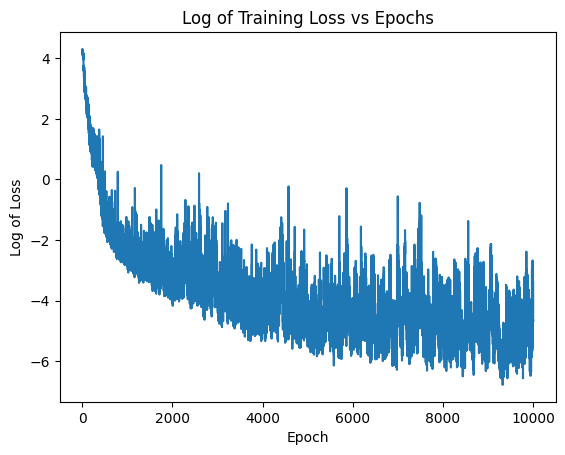

In [20]:
class DGMNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers):
        super(DGMNet, self).__init__()

        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )
        self.output = nn.Linear(hidden_dim, 1)

    def activation(self, x):
        # Swish / SiLU activation (smooth and good for PDEs)
        return x * torch.sigmoid(x)

    def forward(self, t, x):
        # concatenate time and space
        inp = torch.cat([t, x], dim=1)

        h = self.activation(self.input(inp))
        for layer in self.hidden:
            h = self.activation(layer(h))

        return self.output(h)

class DeepGalerkinSolver:
    def __init__(self, H, M, C, D, R, sigma, alpha,
                 T,
                 hidden_dim,
                 n_layers,
                 device="cpu"):

        self.device = device
        self.T = T

        # Convert matrices to tensors
        self.H = torch.tensor(H, dtype=torch.float32, device=device)
        self.M = torch.tensor(M, dtype=torch.float32, device=device)
        self.C = torch.tensor(C, dtype=torch.float32, device=device)
        self.D = torch.tensor(D, dtype=torch.float32, device=device)
        self.R = torch.tensor(R, dtype=torch.float32, device=device)
        self.sigma = torch.tensor(sigma, dtype=torch.float32, device=device)
        self.alpha = torch.tensor(alpha, dtype=torch.float32, device=device)

        self._validate_positive_definite(self.C, "C")
        self._validate_positive_definite(self.R, "R")
        self._validate_strictly_positive_definite(self.D, "D")

        self.dim = self.H.shape[0]

        self.net = DGMNet(self.dim + 1, hidden_dim, n_layers).to(device)

        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-3)

    def _validate_positive_definite(self, A, name):
        """
        Checks if A is symmetric positive definite.
        Raises ValueError if not.
        """

        # Check symmetry
        if not torch.allclose(A, A.T, atol=1e-6):
            raise ValueError(f"Matrix {name} is not symmetric.")

        # Cholesky test
        try:
            torch.linalg.cholesky(A)
        except RuntimeError:
            raise ValueError(f"Matrix {name} is not positive definite.")

    def _validate_strictly_positive_definite(self, A, name):
        """
        Checks if A is strictly positive definite
        (all eigenvalues strictly > 0).
        """

        # Check symmetry
        if not torch.allclose(A, A.T, atol=1e-6):
            raise ValueError(f"Matrix {name} is not symmetric.")

        # Eigenvalue check
        eigenvalues = torch.linalg.eigvalsh(A)
        min_eig = torch.min(eigenvalues)

        if min_eig <= 0:
            raise ValueError(
                f"Matrix {name} is not strictly positive definite. "
                f"Minimum eigenvalue = {min_eig.item():.6e}"
            )

    def pde_residual(self, t, x):
        t.requires_grad_(True)
        x.requires_grad_(True)

        u = self.net(t, x)

        # Time derivative
        u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            create_graph=True
        )[0]

        # First spatial gradient
        grad_u = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            create_graph=True
        )[0]

        # Hessian (loop over dimensions)
        hessian = []
        for i in range(self.dim):
            grad_i = torch.autograd.grad(
                grad_u[:, i],
                x,
                grad_outputs=torch.ones_like(grad_u[:, i]),
                create_graph=True
            )[0]
            hessian.append(grad_i)

        hessian = torch.stack(hessian, dim=2)  # shape: (batch, dim, dim)

        # Diffusion term: 1/2 tr(σσ^T Hessian)
        sigma_sigmaT = self.sigma @ self.sigma.T
        diffusion = 0.5 * torch.einsum("ij,bji->b", sigma_sigmaT, hessian)

        # Drift gradient terms
        Hx = x @ self.H.T
        Malpha = self.alpha @ self.M.T

        drift_term = (grad_u * (Hx + Malpha)).sum(dim=1)

        # Quadratic source terms
        quad_x = torch.einsum("bi,ij,bj->b", x, self.C, x)
        quad_alpha = self.alpha @ self.D @ self.alpha

        residual = (
            u_t.squeeze()
            + diffusion
            + drift_term
            + quad_x
            + quad_alpha
        )

        return residual

    def loss(self, batch_size):

        # Sample interior points
        t = torch.rand(batch_size, 1, device=self.device) * self.T
        x = torch.randn(batch_size, self.dim, device=self.device)

        res = self.pde_residual(t, x)
        pde_loss = torch.mean(res**2)

        # Terminal condition
        x_T = torch.randn(batch_size, self.dim, device=self.device)
        t_T = torch.ones(batch_size, 1, device=self.device) * self.T

        u_T = self.net(t_T, x_T)
        target = torch.einsum("bi,ij,bj->b", x_T, self.R, x_T)

        terminal_loss = torch.mean((u_T.squeeze() - target)**2)

        return pde_loss + terminal_loss

    def train(self, epochs=5000, batch_size=256):

        self.loss_history = []

        for epoch in range(epochs):
            self.optimizer.zero_grad()

            loss = self.loss(batch_size)
            loss.backward()

            self.optimizer.step()

            self.loss_history.append(loss.item())

            if epoch % 250 == 249:
                print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

if __name__ == "__main__":

    # problem matrices (same as coursework spec)
    H = np.array([[0.5, 0.1], [0.1, 0.3]])
    M = np.array([[1.0, 0.5], [0.0, 1.0]])
    C = np.array([[2.0, 0.5], [0.5, 1.0]])
    D = np.array([[2.0, 0.0], [0.0, 1.0]])
    R = np.array([[1.0, 0.0], [0.0, 2.0]])
    sigma = np.array([[0.3, 0.1], [0.0, 0.2]])
    alpha = np.array([1,1])
    T = 1.0

    # Hyperparameters n_layers and hidden_dim
    n_layers = 4
    hidden_dim = 64

    epochs = 10000

    solver = DeepGalerkinSolver(
    H=H,
    M=M,
    C=C,
    D=D,
    R=R,
    sigma=sigma,
    alpha=alpha,
    T=1.0,
    hidden_dim=hidden_dim,
    n_layers=n_layers,
    device="cuda" if torch.cuda.is_available() else "cpu"
    )
    solver.train(epochs=epochs)

    plt.figure()
    plt.plot(range(1, len(solver.loss_history) + 1), np.log(solver.loss_history))
    plt.xlabel("Epoch")
    plt.ylabel("Log of Loss")
    plt.title("Log of Training Loss vs Epochs")
    plt.show()